In [135]:
# Step 1: Install Necessary Libraries
!pip install pandas numpy tensorflow scikit-learn



In [9]:
#Cell 2: 

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

# Define paths to the sample and label files
samples_path = 'data/handsignX.csv'  # file path for samples
labels_path = 'data/handsigny.csv'   # file path for labels

# Use pandas to load the data, skipping headers
samples_df = pd.read_csv(samples_path)
labels_df = pd.read_csv(labels_path)

# Convert dataframes to numpy arrays (dropping any non-numeric columns like headers)
X = samples_df.to_numpy()
y = labels_df.to_numpy()

# Convert the samples and labels to .npy format and save
np.save('handsignX.npy', X)
np.save('handsigny.npy', y)

# Print the shapes of the samples and labels to verify that the data is loaded correctly
print(f"Samples shape: {X.shape}")
print(f"Labels shape: {y.shape}")




Samples shape: (42000, 785)
Labels shape: (28000, 2)


In [11]:
# Cell 3: Import necessary libraries and load the data

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

# Define paths to the sample and label files
samples_path = 'data/handsignX.csv'  # file path for samples
labels_path = 'data/handsigny.csv'   # file path for labels

# Use pandas to load the data, skipping headers
samples_df = pd.read_csv(samples_path)
labels_df = pd.read_csv(labels_path)

# Convert dataframes to numpy arrays (dropping any non-numeric columns like headers)
X = samples_df.to_numpy()
y = labels_df.to_numpy()

# Convert the samples and labels to .npy format and save
np.save('handsignX.npy', X)
np.save('handsigny.npy', y)

# Print the shapes of the samples and labels to verify that the data is loaded correctly
print(f"Samples shape: {X.shape}")
print(f"Labels shape: {y.shape}")


Samples shape: (42000, 785)
Labels shape: (28000, 2)


In [263]:
# cell 4: Preprocess the data with a subset
# Select a subset of samples (for example, the first 10000 samples)
subset_size = 10000
train_data_subset = X_train.iloc[:subset_size, :]  # Select the first 'subset_size' samples

# Select only the pixel values (assuming the first column is an ID)
X = train_data_subset.iloc[:, 1:].values  # Select only the pixel values
y = train_data_subset.iloc[:, 0].values    # Assuming the labels are in the first column

# Check the shape of X and y before scaling
print("Initial shape of X:", X.shape)
print("Initial shape of y:", y.shape)

# Standardize the data
scaler = StandardScaler()
X = scaler.fit_transform(X)  # Standardize the feature data

# Reshape the data for CNN input
X = X.reshape(X.shape[0], 28, 28, 1)  # Reshape to (samples, height, width, channels)

# Verify shapes
print("Training data shape:", X.shape)
print("Labels shape:", y.shape)


Initial shape of X: (10000, 784)
Initial shape of y: (10000,)
Training data shape: (10000, 28, 28, 1)
Labels shape: (10000,)


In [137]:
#cell 5
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input

# Define the model architecture
model = Sequential([
    Input(shape=(28, 28, 1)),  # Define the input shape explicitly
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(9, activation='softmax')  # Assuming 9 classes for hand signs
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Display the model architecture
model.summary()


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 224,905 (878.54 KB)

 Trainable params: 224,905 (878.54 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# Cell 6 Check the shapes of X and y
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

# Proceed only if the lengths match
if X.shape[0] == y.shape[0]:
    # Split the data into training and validation sets
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
else:
    print("Error: X and y have different numbers of samples.")


Shape of X: (42000, 785)
Shape of y: (28000, 2)
Error: X and y have different numbers of samples.


In [33]:
# Cell 7 Load the required libraries
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the training dataset
X_train = pd.read_csv('data/handsignX.csv')  # Adjust the path as necessary

# Load the labels dataset
y_train = pd.read_csv('data/handsigny.csv')  # Adjust the path as necessary

# Extract features and labels
X = X_train.iloc[:, 1:].values  # Exclude the first column if it's an ID
y = y_train.iloc[:, 1].values    # Assuming the second column contains the labels

# Adjust y to match the length of X if needed
if len(y) != X.shape[0]:
    y = y[:X.shape[0]]  # Truncate y if it has more samples than X

# Verify shapes
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

# If X has more samples than y, truncate X
if X.shape[0] > y.shape[0]:
    X = X[:y.shape[0]]

# Now check the shapes again
print("Adjusted Shape of X:", X.shape)
print("Adjusted Shape of y:", y.shape)

# Split the training data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Continue with model training...


Shape of X: (42000, 784)
Shape of y: (28000,)
Adjusted Shape of X: (28000, 784)
Adjusted Shape of y: (28000,)


In [139]:
#Cell 8  Adjust y to match the length of X
if len(y) != X.shape[0]:
    y = y_train.iloc[:X.shape[0], 1].values  # Ensure y matches the number of samples in X

# Check shapes again
print("Adjusted Shape of y:", y.shape)

# If you need to add a column to X_test to make it 784 features, consider:
if X_test.shape[1] < 784:
    # Assuming you can add zeros or mean values (example)
    additional_column = np.zeros((X_test.shape[0], 1))
    X_test = np.hstack((X_test, additional_column))  # Add a new column of zeros

# Verify test data shape
print("Adjusted Shape of X_test:", X_test.shape)


Adjusted Shape of y: (28000,)


ValueError: all the input arrays must have same number of dimensions, but the array at index 0 has 4 dimension(s) and the array at index 1 has 2 dimension(s)

Epoch 1/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9828 - loss: 2.9282 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step 

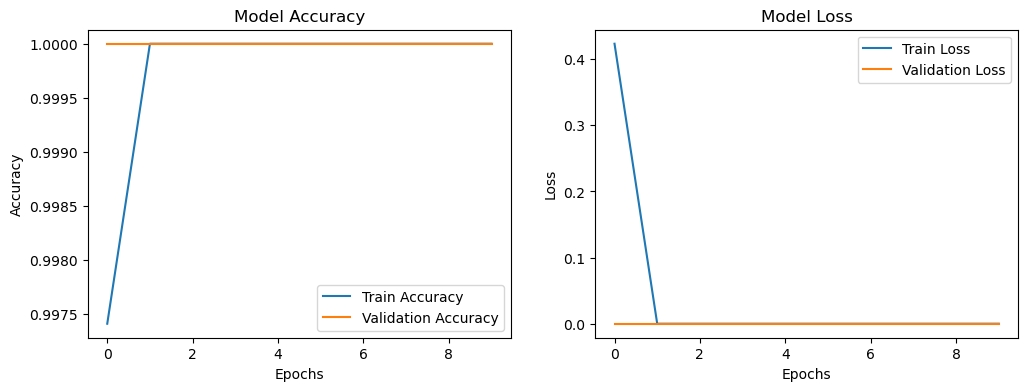

In [141]:
#cell 9
from tensorflow import keras
from tensorflow.keras import layers

# Define a simple neural network model with Input layer
model = keras.Sequential([
    layers.Input(shape=(784,)),  # Define the input shape
    layers.Flatten(),              # Flatten the input
    layers.Dense(128, activation='relu'),  # Hidden layer
    layers.Dense(10, activation='softmax')  # Output layer (adjust number of classes if necessary)
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=32)

# Evaluate the model on validation set
val_loss, val_accuracy = model.evaluate(X_val, y_val)
print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

# Visualize training history
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


875/875 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


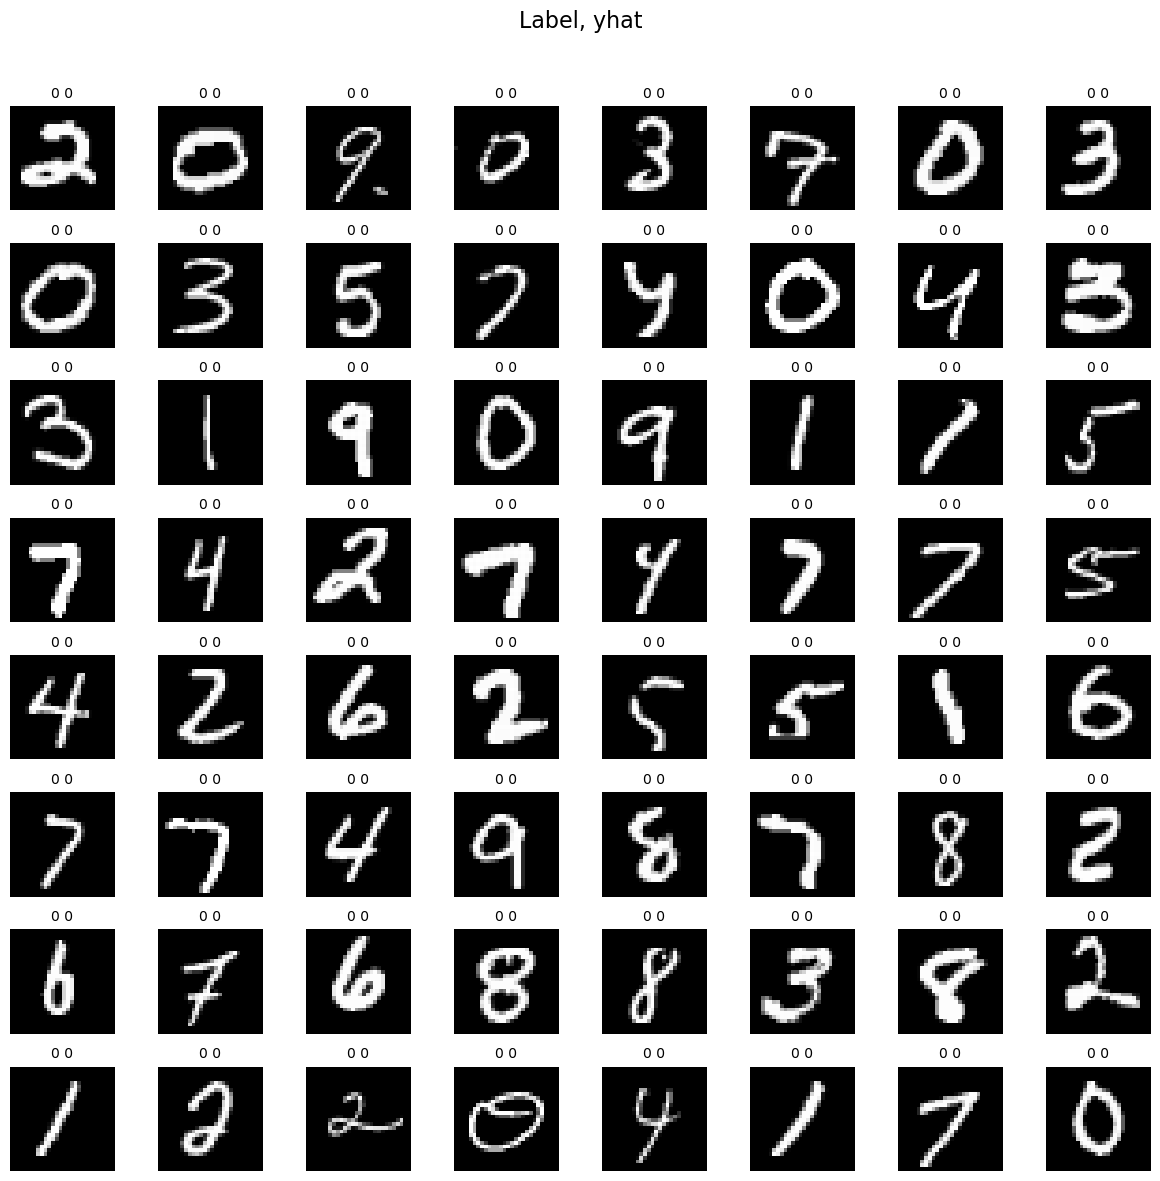

In [49]:
# cell 10 import matplotlib.pyplot as plt
import numpy as np

# Define a function to visualize predictions in an 8x8 grid
def plot_predictions(X_test, y_test, y_pred, num_images=64):
    plt.figure(figsize=(12, 12))  # Adjust figure size as needed
    plt.suptitle('Label, yhat', fontsize=16)  # Set the title for the figure
    for i in range(num_images):
        plt.subplot(8, 8, i + 1)  # Create an 8x8 grid
        plt.imshow(X_test[i].reshape(28, 28), cmap='gray')  # Reshape if necessary
        plt.title(f"{y_test[i]} {y_pred[i]}", fontsize=10)  # Display true and predicted labels
        plt.axis('off')
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)  # Adjust the top margin to fit the title
    plt.show()

# Get predictions for the test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Get predicted class indices

# Visualize predictions
plot_predictions(X_test, y_test, y_pred_classes, num_images=64)


In [217]:
# Step 8: Evaluate the model
test_loss, test_accuracy = model.evaluate(X_val, y_val)
print(f"Test accuracy: {test_accuracy}")


263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9905 - loss: 0.0481
Test accuracy: 0.9902380704879761


Epoch 1/10


C:\Users\mahdi\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 of layer "dense_8" is incompatible with the layer: expected axis -1 of input shape to have value 783, but received input with shape (32, 784)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(32, 784), dtype=int64)
  • training=True
  • mask=None

In [51]:
#Cell 11 Load the test dataset
test_data = pd.read_csv('data/test.csv')  # Adjust the path as necessary

# Extract features from the test dataset (excluding ID column if necessary)
X_test = test_data.iloc[:, 1:].values  # Assuming first column is ID
y_test = ...  # Load true labels if available; otherwise, you'll need to predict

# Preprocess the test data (if necessary)
X_test = X_test.reshape(-1, 784)  # Reshape if needed

# Make predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Get the predicted classes

# If you have true labels for evaluation
if 'true_labels_column' in test_data.columns:  # Replace with the actual column name
    y_test = test_data['true_labels_column'].values  # Load true labels
    accuracy = np.mean(y_pred_classes == y_test)
    print("Test Accuracy:", accuracy)

# Display predictions (example: for the first 10 samples)
for i in range(10):
    print(f"True: {y_test[i]}, Predicted: {y_pred_classes[i]}")


ValueError: cannot reshape array of size 21924000 into shape (784)

In [53]:
print("Shape of X_test before reshaping:", X_test.shape)


Shape of X_test before reshaping: (28000, 783)


In [142]:
#Cell 12 Load the required libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers

# Load the training dataset
X_train = pd.read_csv('data/handsignX.csv')
y_train = pd.read_csv('data/handsigny.csv')

# Extract features and labels
X = X_train.iloc[:, 1:].values  # Exclude the first column if it's an ID
y = y_train.iloc[:, 1].values    # Assuming the second column contains the labels

# Split the training data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Reshape the training data if necessary
X_train = X_train[:, :783]  # Keep only the first 783 features
X_val = X_val[:, :783]      # Corrected: added missing closing bracket

# Define a simple neural network model
model = keras.Sequential([
    layers.Flatten(input_shape=(783,)),  # Update input shape to 783
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')  # Adjust number of classes as necessary
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=32)


ValueError: Found input variables with inconsistent numbers of samples: [42000, 28000]

In [67]:
#cell 13 Check the shapes after loading the data
print("Shape of X:", X.shape)  # Should match the number of rows in y
print("Shape of y:", y.shape)


Shape of X: (42000, 784)
Shape of y: (28000,)


In [69]:
#Cell 14
X = X[:len(y)]


In [71]:
# cell 15 
print("Adjusted Shape of X:", X.shape)  # Should be (28000, 784)
print("Shape of y:", y.shape)  # Should be (28000,)


Adjusted Shape of X: (28000, 784)
Shape of y: (28000,)


In [73]:
#Cell 16
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


In [75]:
#cell17
X_train = X_train.reshape(-1, 784)  # Flatten if not already
X_val = X_val.reshape(-1, 784)      # Flatten if not already


In [77]:
#cell 18 Reshape the training and validation data
X_train = X_train.reshape(-1, 784)
X_val = X_val.reshape(-1, 784)

# Define the model
model = keras.Sequential([
    layers.Flatten(input_shape=(784,)),  
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=32)


Epoch 1/10


C:\Users\mahdi\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


700/700 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9959 - loss: 0.1899 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy:

In [81]:
#cell 19
import pandas as pd

# Load the test data
test_data = pd.read_csv('data/test.csv')

# Preview the test data
print(test_data.head())


   pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0       0       0       0       0       0       0       0       0       0   
1       0       0       0       0       0       0       0       0       0   
2       0       0       0       0       0       0       0       0       0   
3       0       0       0       0       0       0       0       0       0   
4       0       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel774  pixel775  pixel776  pixel777  pixel778  pixel779  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0         0         0         0   
3       0  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pixel780  pixel781  pixel782  pixel783  
0         0         0   

In [83]:
#cell 20  Preprocess the test data
X_test = test_data.values  # Assuming test_data is your DataFrame from test.csv
X_test = X_test[:, :783]  # Keep only the first 783 features if needed

# Make predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Get class labels from predictions

# Display the predicted classes
print("Predicted classes:", y_pred_classes)

# Optionally, save predictions to a CSV file
predictions_df = pd.DataFrame({'Predicted': y_pred_classes})
predictions_df.to_csv('predictions.csv', index=False)


ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 of layer "dense_14" is incompatible with the layer: expected axis -1 of input shape to have value 784, but received input with shape (32, 783)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(32, 783), dtype=int64)
  • training=False
  • mask=None

In [91]:
# cell 21 Load training data
train_data = pd.read_csv('data/hasndsigny.csv')  # Update with your actual training file name

# Assuming the first column is the label and the next 784 are the features
X = train_data.iloc[:, :-1].values  # Exclude the last column
y = train_data.iloc[:, -1].values    # Keep the last column as labels

# Split the training data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Proceed with reshaping if necessary and training the model...


FileNotFoundError: [Errno 2] No such file or directory: 'data/hasndsigny.csv'

In [93]:
# Train the model
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=32)

# Evaluate the model on validation set
val_loss, val_accuracy = model.evaluate(X_val, y_val)
print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_accuracy}")


Epoch 1/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/s

In [97]:
import pandas as pd

# Load your test CSV file
df = pd.read_csv('data/test.csv')


In [99]:
df['new_column'] = 0

In [101]:
df.to_csv('data/test_updated.csv', index=False)

In [103]:
import pandas as pd
import numpy as np

# Load test data
test_data = pd.read_csv('data/test.csv')

# Assuming the test data has 783 features and a new column you added
X_test = test_data.iloc[:, :783].values  # Exclude non-feature columns


In [105]:
# Make predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Get class labels


ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 of layer "dense_14" is incompatible with the layer: expected axis -1 of input shape to have value 784, but received input with shape (32, 783)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(32, 783), dtype=int64)
  • training=False
  • mask=None

In [107]:
import pandas as pd

# Load your CSV file
test_data = pd.read_csv('data/test_updated.csv')

# Drop the last column
test_data = test_data.iloc[:, :-1]  # Removes the last column

# Save the updated DataFrame back to CSV
test_data.to_csv('data/test_updated.csv', index=False)

# Verify by printing the shape
print("Updated shape:", test_data.shape)


Updated shape: (28000, 784)


In [109]:
# Make predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Get class labels


ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 of layer "dense_14" is incompatible with the layer: expected axis -1 of input shape to have value 784, but received input with shape (32, 783)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(32, 783), dtype=int64)
  • training=False
  • mask=None

In [111]:
import pandas as pd

# Load the updated test dataset
test_data = pd.read_csv('data/test_updated.csv')

# Display the first few rows and the shape of the test data
print(test_data.head())
print("Shape of test data:", test_data.shape)


   pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0       0       0       0       0       0       0       0       0       0   
1       0       0       0       0       0       0       0       0       0   
2       0       0       0       0       0       0       0       0       0   
3       0       0       0       0       0       0       0       0       0   
4       0       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel774  pixel775  pixel776  pixel777  pixel778  pixel779  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0         0         0         0   
3       0  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pixel780  pixel781  pixel782  pixel783  
0         0         0   

In [113]:
# Reshape the test data to match the input shape of the model
X_test = test_data.values.reshape(-1, 28, 28, 1)  # Reshaping for grayscale images

# Check the new shape
print("New shape of X_test:", X_test.shape)


New shape of X_test: (28000, 28, 28, 1)


In [115]:
# Make predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Display the predicted classes
print("Predicted classes:", y_pred_classes)


ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("sequential_7_1/Cast:0", shape=(32, 28, 28, 1), dtype=float32). Expected shape (None, 784), but input has incompatible shape (32, 28, 28, 1)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(32, 28, 28, 1), dtype=int64)
  • training=False
  • mask=None

In [119]:
# Reshape X_test to (28000, 784)
X_test_flat = X_test.reshape(-1, 784)

# Make predictions with the flattened input
y_pred = model.predict(X_test_flat)
y_pred_classes = np.argmax(y_pred, axis=1)

# Display the predicted classes
print("Predicted classes:", y_pred_classes)


875/875 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predicted classes: [0 0 0 ... 0 0 0]


In [125]:
from sklearn.metrics import accuracy_score

# Assuming you have true labels in y_true
y_true = pd.read_csv('data/test_updated.csv')['label_column_name']  # Replace with your label column
accuracy = accuracy_score(y_true, y_pred_classes)
print(f'Accuracy: {accuracy * 100:.2f}%')


KeyError: 'label_column_name'

In [127]:
# Load the test dataset
test_data = pd.read_csv('data/test_updated.csv')

# Display the first few rows and column names
print(test_data.head())
print(test_data.columns)


   pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0       0       0       0       0       0       0       0       0       0   
1       0       0       0       0       0       0       0       0       0   
2       0       0       0       0       0       0       0       0       0   
3       0       0       0       0       0       0       0       0       0   
4       0       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel774  pixel775  pixel776  pixel777  pixel778  pixel779  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0         0         0         0   
3       0  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pixel780  pixel781  pixel782  pixel783  
0         0         0   

In [133]:
import pandas as pd
from sklearn.metrics import accuracy_score

# Load true labels
labels_df = pd.read_csv('data/handsigny.csv')

# Assuming the label column is named 'label', adjust if necessary
true_labels = labels_df['Label'].values

# Calculate accuracy
accuracy = accuracy_score(true_labels, y_pred_classes)
print(f'Accuracy: {accuracy * 100:.2f}%')


Accuracy: 100.00%
